<a href="https://colab.research.google.com/github/RagineeS/Capgemini_Assignment/blob/main/RESTAURANT_SALES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("SalesData.csv")

#### Apply these steps first :
- info
- shape
- datatypes
- null values
- duplicates

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        254 non-null    int64  
 1   Date            254 non-null    object 
 2   Product         254 non-null    object 
 3   Price           254 non-null    float64
 4   Quantity        254 non-null    float64
 5   Purchase Type   254 non-null    object 
 6   Payment Method  254 non-null    object 
 7   Manager         254 non-null    object 
 8   City            254 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 18.0+ KB


In [4]:
df.shape

(254, 9)

In [5]:
df.dtypes

,0
Order ID,int64
Date,object
Product,object
Price,float64
Quantity,float64
Purchase Type,object
Payment Method,object
Manager,object
City,object


In [6]:
df["Product"].unique()

array(['Fries', 'Beverages', 'Sides & Other', 'Burgers',
       'Chicken Sandwiches'], dtype=object)

In [7]:
df.isnull().sum()

,0
Order ID,0
Date,0
Product,0
Price,0
Quantity,0
Purchase Type,0
Payment Method,0
Manager,0
City,0


In [8]:
df[df.duplicated()]

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City


In [9]:
df.Manager.unique()

array(['Tom      Jackson', '       Pablo Perez', 'Joao    Silva',
       'Walter Muller', 'Remy    Monet', 'Remy Monet',
       '       Remy Monet', 'Remy     Monet', 'Pablo Perez',
       'Pablo   Perez', 'Pablo  Perez', 'Pablo    Perez', 'Joao Silva',
       'Tom Jackson'], dtype=object)

In [10]:
len(df.Manager.unique()[0])

16

In [11]:
df["Manager"] = df["Manager"].str.strip().str.replace(r"\s+"," ",regex=True)

In [12]:
df["Manager"].unique()

array(['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller',
       'Remy Monet'], dtype=object)

#### Fixing the datatypes

In [13]:
df.Quantity = df.Quantity.astype(int)

In [14]:
df

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...
249,10709,28-12-2022,Sides & Other,4.99,200,Drive-thru,Gift Card,Walter Muller,Berlin
250,10710,29-12-2022,Burgers,12.99,754,Drive-thru,Gift Card,Walter Muller,Berlin
251,10711,29-12-2022,Chicken Sandwiches,9.95,281,Drive-thru,Gift Card,Walter Muller,Berlin
252,10712,29-12-2022,Fries,3.49,630,Drive-thru,Gift Card,Walter Muller,Berlin


#### Fixing the Date Column.

In [15]:
df.Date = pd.to_datetime(df.Date,format="mixed")

In [16]:
df.Date.head(2)

,Date
0,2022-07-11
1,2022-07-11


In [17]:
df.Date.dt.month.head(2)

,Date
0,7
1,7


#### Most Preferred Payment Method?

In [18]:
df.sample(3)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
237,10697,2022-12-26,Fries,3.49,630,In-store,Cash,Walter Muller,Berlin
123,10583,2022-03-12,Beverages,2.95,677,Online,Credit Card,Tom Jackson,London
37,10494,2022-11-15,Sides & Other,4.99,200,In-store,Credit Card,Pablo Perez,Madrid


In [19]:
df["Payment Method"].value_counts()

,count
Payment Method,
Credit Card,120
Cash,76
Gift Card,58


#### What is the most Selling Product?
- by Quantity
- by Revenue

In [20]:
df.groupby("Product")["Quantity"].sum()

,Quantity
Product,
Beverages,34938
Burgers,28996
Chicken Sandwiches,11132
Fries,32016
Sides & Other,9800


In [21]:
df["Revenue"] = df["Price"] * df["Quantity"]
df.groupby("Product")["Revenue"].sum()

,Revenue
Product,
Beverages,103067.10
Burgers,376658.04
Chicken Sandwiches,114602.50
Fries,125602.14
Sides & Other,48902.00


#### Which city had maximum revenue?
and
#### Which Manager earned maximum revenue?

In [22]:
df.groupby("City")["Revenue"].sum()

,Revenue
City,
Berlin,100492.73
Lisbon,241509.38
London,211001.83
Madrid,136098.22
Paris,79729.62


In [23]:
df.groupby("Manager")["Revenue"].sum().reset_index().sort_values(by="Revenue",ascending=False)

,Manager,Revenue
0,Joao Silva,241509.38
3,Tom Jackson,211001.83
1,Pablo Perez,136098.22
4,Walter Muller,100492.73
2,Remy Monet,79729.62


#### Average Revenue of November & December?

In [24]:
df[df["Date"].dt.month==11]["Revenue"].mean()

np.float64(2967.8207216494843)

In [25]:
df[df["Date"].dt.month==12]["Revenue"].mean()

np.float64(3192.758191489363)

### Compare Revenue by Purchase Type.

In [26]:
df.groupby("Purchase Type")["Revenue"].sum()

,Revenue
Purchase Type,
Drive-thru,178422.12
In-store,285491.09
Online,304918.57


# HR Analytics

In [27]:
df = pd.read_csv("HR_Data.csv",encoding="unicode-escape")

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404819 entries, 0 to 404818
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          404819 non-null  int64  
 1   Employee_ID         404819 non-null  object 
 2   Full_Name           404819 non-null  object 
 3   Department          404819 non-null  object 
 4   Job_Title           404819 non-null  object 
 5   Hire_Date           404818 non-null  object 
 6   Location            404818 non-null  object 
 7   Performance_Rating  404818 non-null  float64
 8   Experience_Years    404818 non-null  float64
 9   Status              404818 non-null  object 
 10  Work_Mode           404818 non-null  object 
 11  Salary_INR          404818 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 37.1+ MB


In [29]:
df.drop(columns= "Unnamed: 0",inplace=True)

In [30]:
df.columns

Index(['Employee_ID', 'Full_Name', 'Department', 'Job_Title', 'Hire_Date',
       'Location', 'Performance_Rating', 'Experience_Years', 'Status',
       'Work_Mode', 'Salary_INR'],
      dtype='object')

In [31]:
df["Hire_Date"]=pd.to_datetime(df["Hire_Date"])

In [32]:
df["Department"].unique()

array(['IT', 'Marketing', 'HR', 'Operations', 'Finance', 'Sales', 'R&D'],
      dtype=object)

In [33]:
df["Job_Title"].unique()

array(['Software Engineer', 'SEO Specialist', 'HR Manager',
       'Logistics Coordinator', 'Finance Manager', 'Account Manager',
       'Financial Analyst', 'Sales Executive', 'Operations Executive',
       'HR Executive', 'Sales Director', 'DevOps Engineer',
       'Content Strategist', 'Marketing Executive', 'Research Scientist',
       'Accountant', 'IT Manager', 'Supply Chain Manager', 'Data Analyst',
       'Talent Acquisition Specialist', 'Product Developer',
       'Operations Director', 'CTO', 'Business Development Manager',
       'Lab Technician', 'CFO', 'Brand Manager', 'HR Director',
       'Innovation Manager', 'Data Anal'], dtype=object)

In [34]:
df["Performance_Rating"].mean().round()

np.float64(3.0)

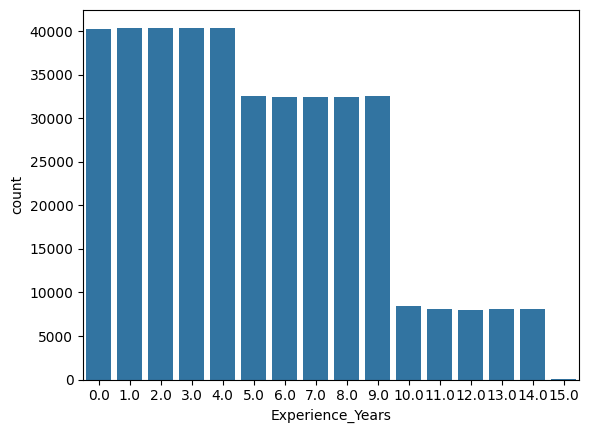

In [35]:
import seaborn as sns
sns.countplot(x='Experience_Years',data=df);

#### What is the distribution of Employee Status (Active,Resigned,Retired,Terminated)?

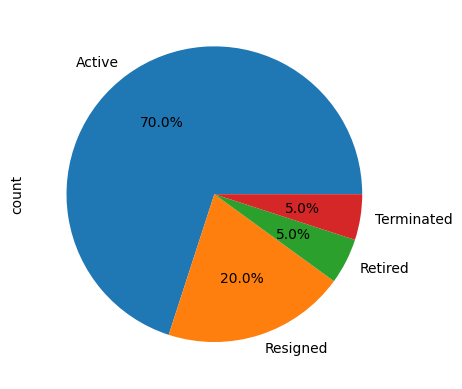

In [36]:
status = df["Status"].value_counts()
status.plot(kind="pie",color="mygr",autopct = "%1.1f%%");

What is the distribution of Work Modes?

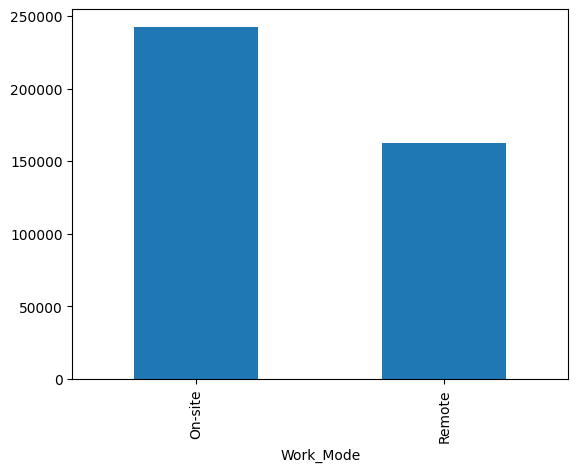

In [37]:
df['Work_Mode'].value_counts().plot(kind='bar');

#### How many employees are there in each department?

In [38]:
df["Department"].value_counts()

,count
Department,
IT,121637
Sales,80654
Operations,60886
Marketing,49045
Finance,40230
HR,32144
R&D,20223


#### What is the average salary by department?

In [39]:
df.groupby('Department')['Salary_INR'].mean().astype(int)

,Salary_INR
Department,
Finance,940775
HR,742768
IT,1130536
Marketing,770763
Operations,755597
R&D,799574
Sales,793570


#### Which Job Title has the highest average salary?